# Exploratory Data Analysis
### Heart Disease Data

In [5]:
# import python packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
# plotin SVG format since this format is more sharp and legible
%config InlineBackend.figure_format = 'svg'

from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

In [6]:
df = pd.read_csv('../data/heart.csv')

In [7]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Features:

- Age: age in years;
- Sex: 1 = male; 0 = female;
- Cp: chest pain type: 0 - Typical angina; 1 - atypical angina; 2 - non-anginal pain; 3 - asymptomatic;
- trestbps: resting blood pressure (in mm Hg on admission to the hospital)
- chol: serum cholestoral in mg/dl
- fbs: fastin blood sugar: 1 - true; 0 - false)
- restecg: resting electrocardiographic results: 0 - normal ; 1 - wave abornamility - T wave inversions and/or ST elevation or depression of > 0.05 mV; 2 - showing probable or definite left ventricular hypertrophy by Estes' criteria
- thalach: maximum heart rate achieved
- exang: exercise induced angina: 1 - yes; 0 - no
- oldpeak: ST depression induced by exercise relative to rest
- slope: the slope of the peak exercise ST segment: 0 - upsloping; 1 - flat; 2 - downsloping;
- ca: number of major vessels (0-3) colored by flourosopy
- thal: 1 - normal; 2 - fixed defect; 3 - reversable defect **CHECK**
- target: 0 - Healthy; 1 - sick (heart disease)

## We can divide these features into two groups: quantitative and categorical
- Quantitative features: Age, trestbps, chol, thalach, oldpeak
- Categorical features: sex, cp, fbs, restecg, exang, slope, ca, thal

In [8]:
numerical_feat = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_feat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

In [9]:
# transform categorical values (sex and exang) for easier reading
df['sex'] = df['sex'].apply(lambda x: 'male' if x == 1 else 'female')
df['exang'] = df['exang'].map({1: 'Yes', 0: 'No'})

## Dataset analysis

In [10]:
df.shape

(1025, 14)

In [11]:
# verify feature name
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [12]:
# check data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   object 
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   object 
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 112.2+ KB


In [13]:
# let's see the statistics of the dataset
df.describe()

,age,cp,trestbps,chol,fbs,restecg,thalach,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Data Visualization

In [15]:
# configrue plots (size and style)
plt.rcParams['figure.figsize'] = (12,8) # figure size
sns.set_style('darkgrid') # style

## Age

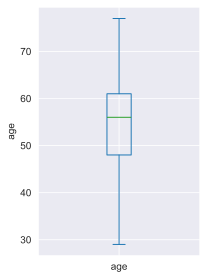

In [16]:
# boxplot of age
ax = (df['age'].plot.box(figsize=(3,4)))
ax.set_ylabel('age')

plt.tight_layout()
plt.show()

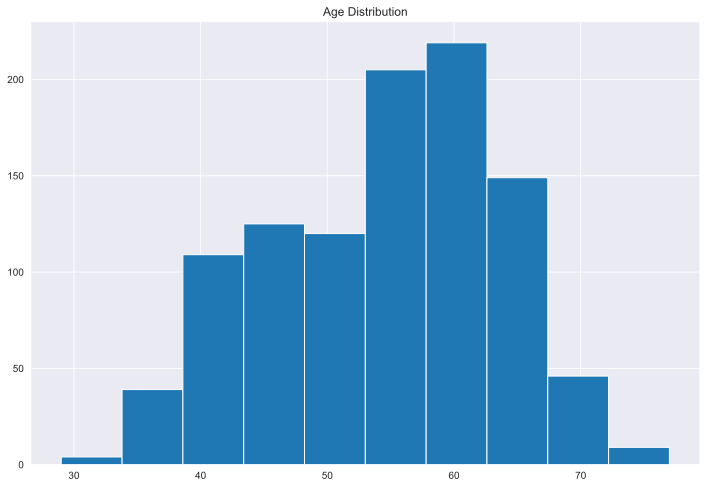

In [19]:
# histogram of age
df['age'].hist(grid=True, bins=10)
plt.title('Age Distribution')
plt.show()

## Density plot using seaborn

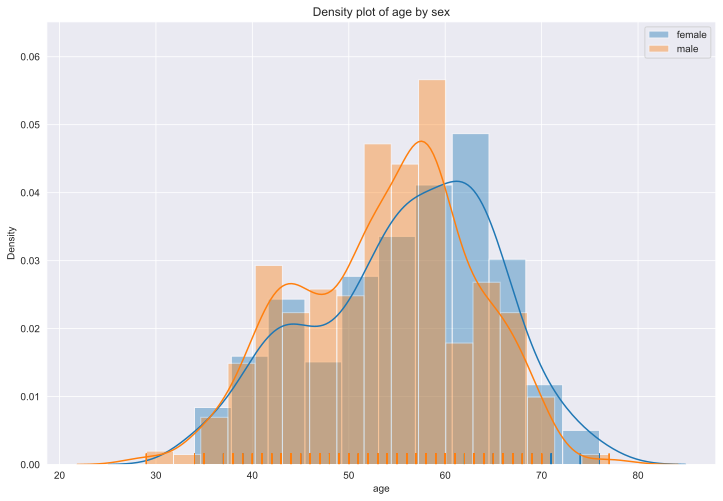

In [20]:
sns.distplot(df[df['sex'] == 'female']['age'], rug = True, hist = True, label = 'female')
sns.distplot(df[df['sex'] == 'male']['age'], rug = True, hist = True, label = 'male')
plt.legend()
plt.title('Density plot of age by sex')
plt.show()

### Density graphs show the smoothed distribution of points along the numerical axis. The density peaks where there is the highest concetration points. In sum, density graphs can be considered smoothed histograms.

## Using Plotly


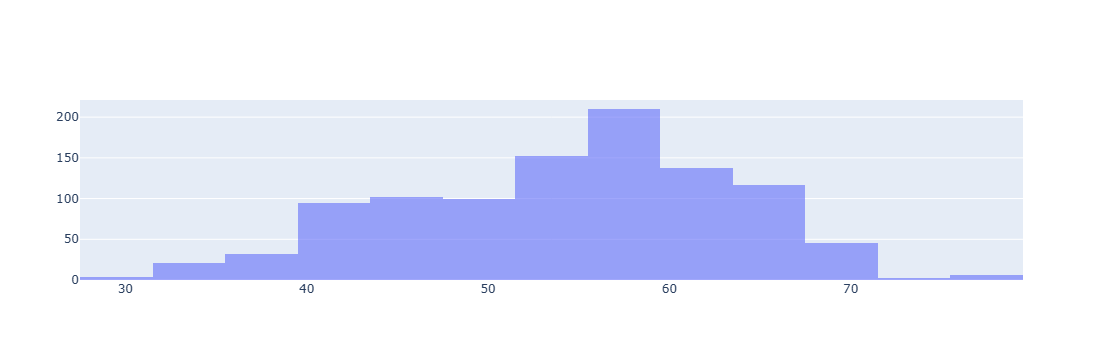

In [22]:
# lets draw a histogram for the 'Age' feature
age = df['age']
layout = go.Layout(barmode = 'overlay')
data = go.Histogram(x = age, opacity =  0.6, xbins = {'size' : 4})
fig = go.Figure(data=[data], layout = layout)

import plotly.offline as py

py.offline.iplot(fig)

## Density plots using seaborn


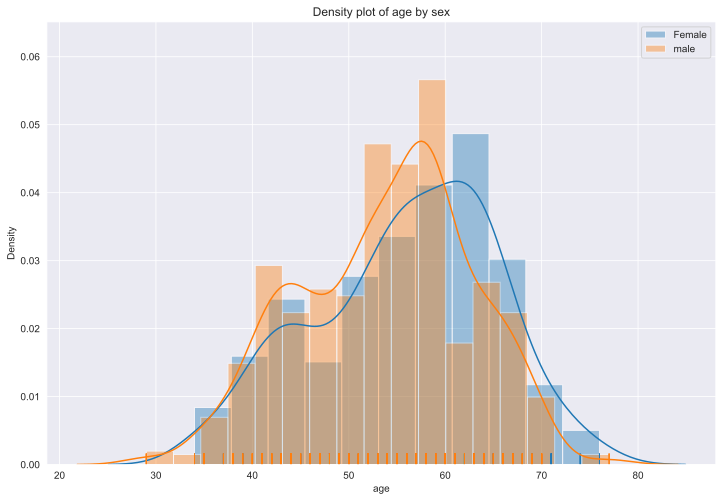

In [25]:
sns.distplot(df[df['sex'] == 'female']['age'], rug = True, hist = True, label = 'Female')
sns.distplot(df[df['sex'] == 'male']['age'], rug = True, hist = True, label = 'male')
plt.legend()
plt.title('Density plot of age by sex')
plt.show()

## Resting blood pressure (in mm Hg on admission to the hospital)

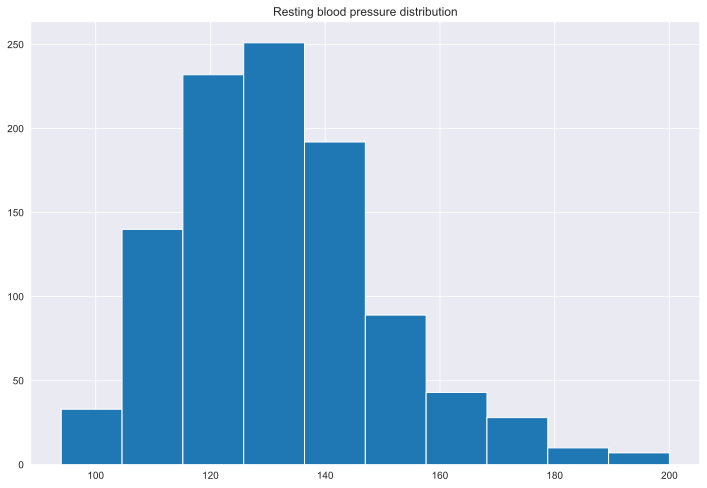

In [27]:
df['trestbps'].hist()
plt.title('Resting blood pressure distribution')
plt.show()

## Let's create a density plot

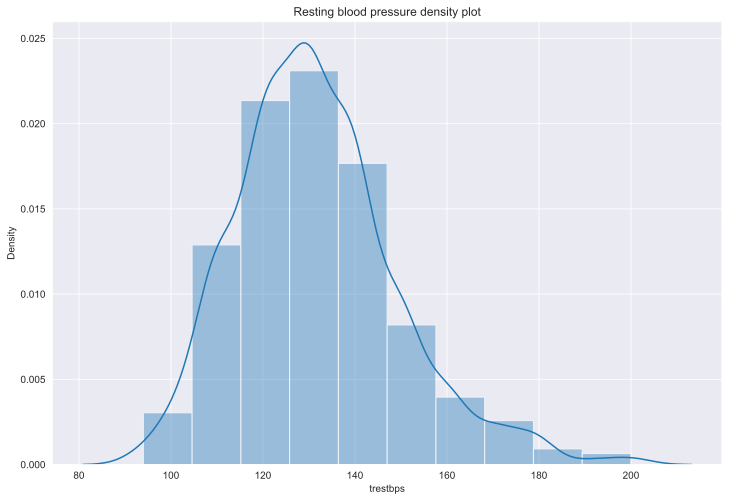

In [32]:
sns.distplot(df['trestbps'], bins = 10)
plt.title('Resting blood pressure density plot')
plt.show()

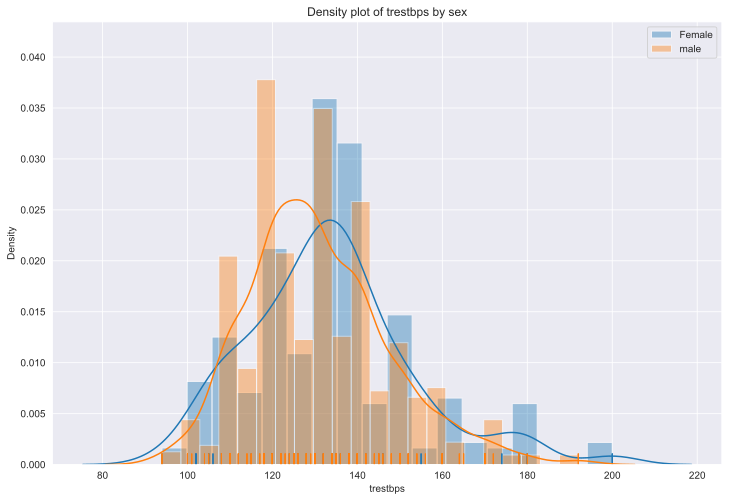

In [33]:
sns.distplot(df[df['sex'] == 'female']['trestbps'], rug = True, hist = True, label = 'Female')
sns.distplot(df[df['sex'] == 'male']['trestbps'], rug = True, hist = True, label = 'male')
plt.legend()
plt.title('Density plot of trestbps by sex')
plt.show()

## Plot a histogram for all continuous variables using df.hist()

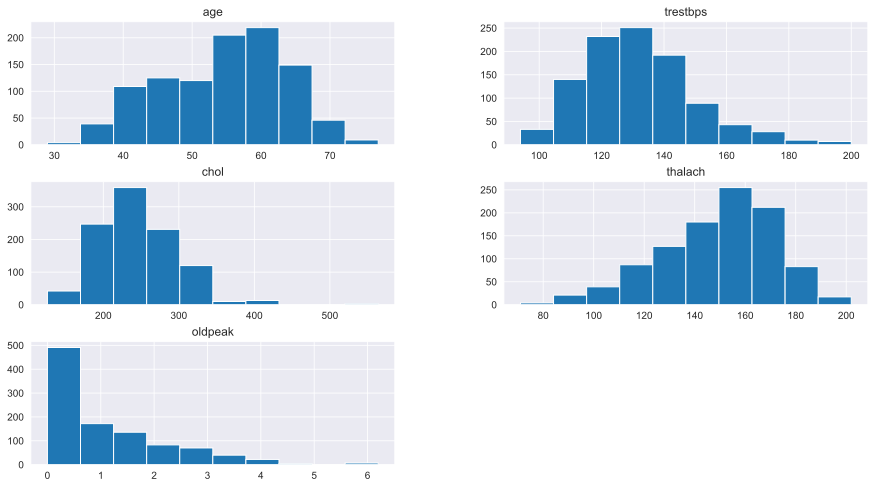

In [36]:
plt.rcParams['figure.figsize'] = (15,8)
df[['age','trestbps', 'chol', 'thalach', 'oldpeak']].hist()
plt.show()

## Check for outliers using boxplots

<Axes: xlabel='oldpeak'>

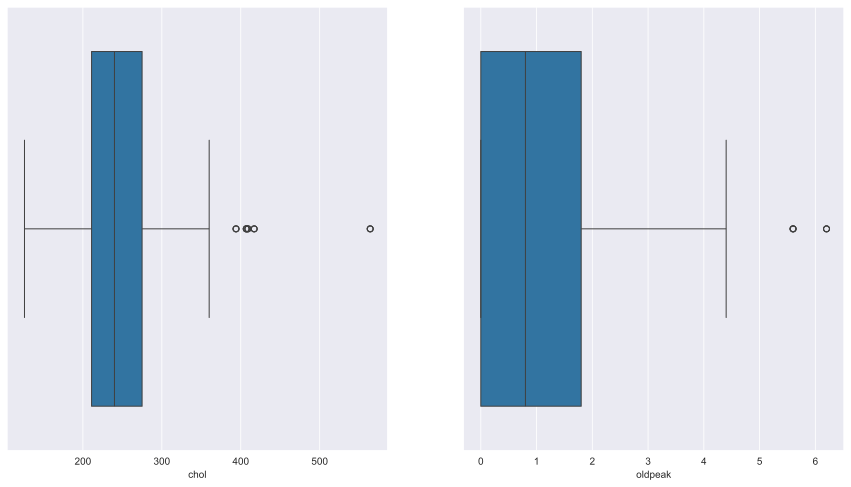

In [40]:
fig, axes = plt.subplots(nrows = 1, ncols = 2)
sns.boxplot(x = 'chol', data = df, orient = 'v', ax = axes[0])
sns.boxplot(x = 'oldpeak', data = df, orient = 'v', ax = axes[1])

## Categorical features

### Let's start with the target variable to see the rate of people with and without heart diseas

In [42]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [43]:
# let's check the proportion of men and women
df['sex'].value_counts()

sex
male      713
female    312
Name: count, dtype: int64

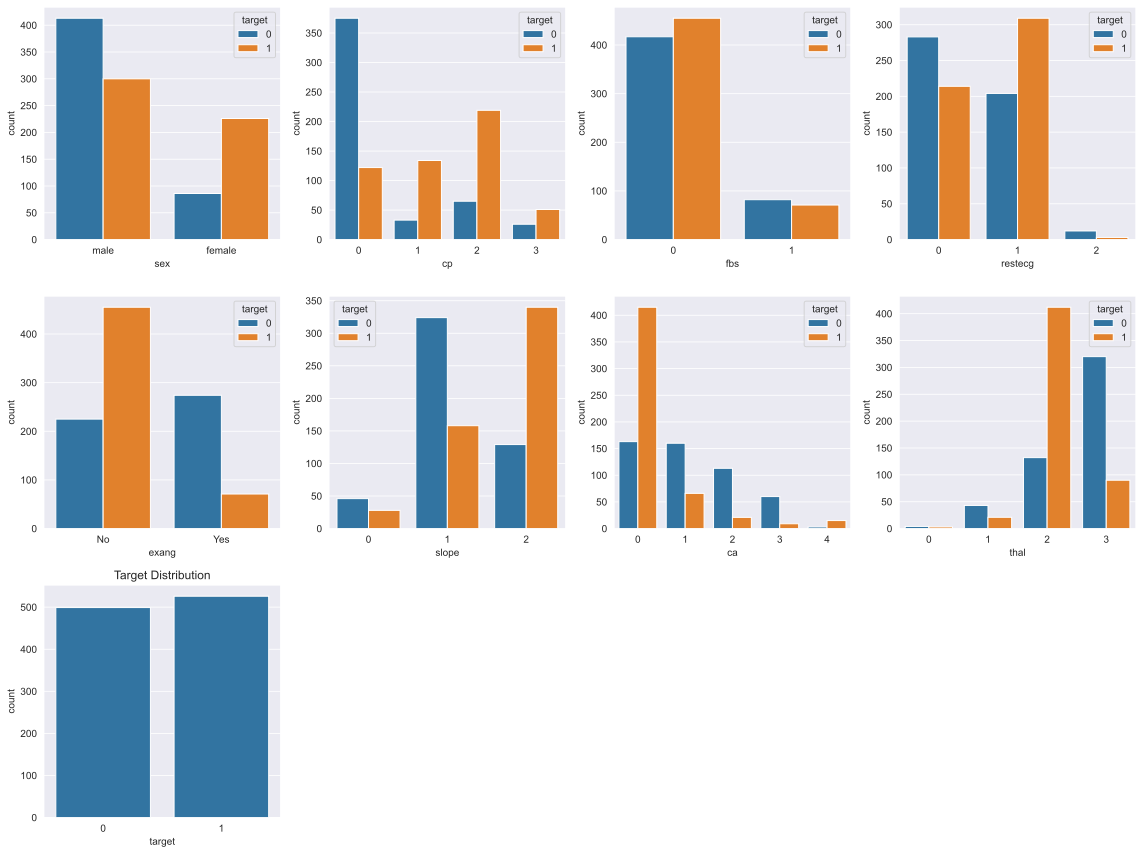

In [52]:
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize = (16,12))

numerical_feat = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_feat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

axes = axes.flatten()

for idx, feature in enumerate(categorical_feat):
    ax = axes[int(idx)]
    if feature  != 'target':
        sns.countplot(x=feature, hue='target', data=df, ax=ax)
    else:
        # avoid leaving the 'target' plot completely blank/empty
        sns.countplot(x=feature, data=df, ax=ax)
        ax.set_title('Target Distribution')

# Hide any empty plots
for empty_idx in range(len(categorical_feat), len(axes)):
    fig.delaxes(axes[empty_idx])

plt.tight_layout()
plt.show()

## Let's perform multivariate analysis, comparing the number of healthy and unhealthy people by sex

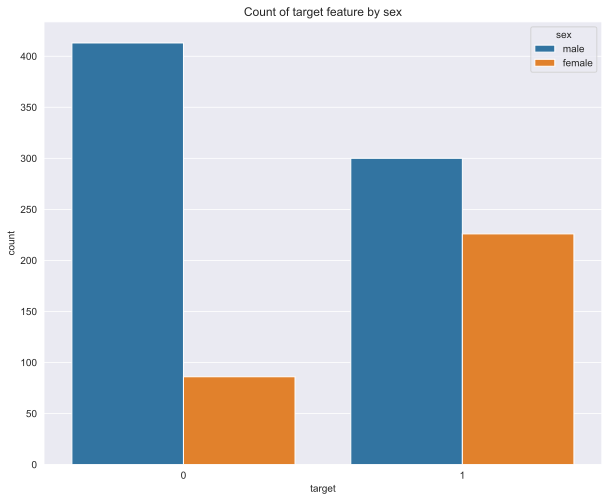

In [54]:
plt.rcParams['figure.figsize'] = (10, 8)
sns.countplot(x='target', hue='sex', data=df)
plt.title('Count of target feature by sex')
plt.show()

### From the plots, the number of healthy male is greater then those unhealthy. For women, the number of unhealthy women is higher.

In [55]:
pd.crosstab(df['sex'], df['target'], normalize=True)

target,0,1
sex,,
female,0.083902,0.220488
male,0.402927,0.292683


In [ ]:
location & variability estimates, distributions, correlation, multivariable EDA
summary stats, boxplots, histograms, correlation heatmap
